# Oppgave 4: Databehandling -- kunder, sparing og formuesfordeling

* Cellen under leser inn noe kundedata
* Dataen inneholder en liste av dictionarier med følgende "felt" eller nøkler:
     - "fornavn"
     - "etternavn"
     - "startsaldo"

In [45]:
import json
with open("kundedata1.json", 'r') as file:
    kundedata = json.load(file)
info = f"""Listen inneholder data om {len(kundedata)} kunder.
For hver kunde har vi data om {list(kundedata[0].keys())}"""
print(info)

Listen inneholder data om 2000 kunder.
For hver kunde har vi data om ['fornavn', 'etternavn', 'startsaldo']


# 4.1: Klassifisering og bruk av data

* Lag et program som går gjennom listen og regner ut hvordan saldo på sparekonto vokser over tid.
* Ta i første omgang utgangspunkt i at alle kunder sparer et fast terminbeløp $n$ ganger i året, til en fornuftig rente $r$

* Hvordan er fordelingen av sparepenger blant kundene? -- lag et histogram med pyplot (plt.hist(.....)) som viser dette
* Utifra fordelingen av sparepenger -- sett noen fornuftige grenser for foreksempel "lite bemidlet", "middels bemidlet" og "rike" kunder
* Oppdater dataene med disse klassifiseringene, og eventuelt annen nyttig info (gjennonsnittssaldo før/etter, max/min saldo..)
  - Her kan du gjerne gjøre "kundedata" listen til et felt i en annen datastruktur
* Vis fordeling med et kake-diagram og histogram
* Hvordan endrer denne fordelingen seg over tid?
                                        

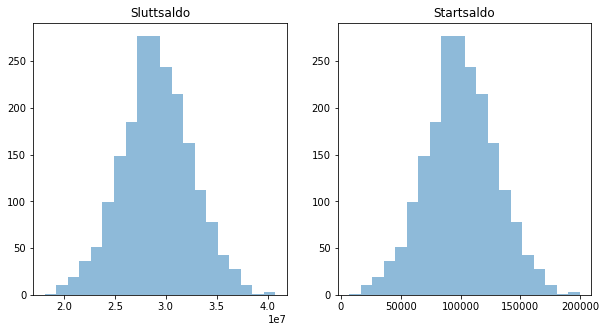

I snitt har kundene 100359 kr på konto ved start
    Kunden med lavest saldo har 6887 på konto
    Kunden med høyest saldo har 199727 på konto

    I snitt har kundene 29105633 kr på konto ved slutt
    Kunden med lavest saldo har 18132877 på konto
    Kunden med høyest saldo har 40770535 på konto


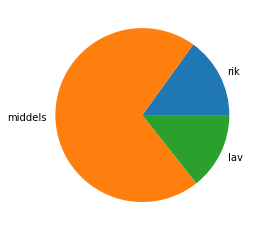

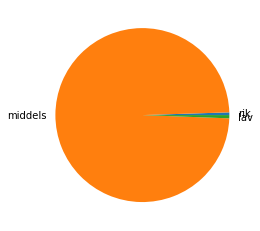

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pprint

pp = pprint.PrettyPrinter(indent=4)

# Gå over kundelisten og legg inn sluttsaldo
# Vi sparer 1000kr/mnd, i 10 år, p.a. rente på 5%
P = 1000
r = 0.1
n=12
t_slutt = 50

# Lag sparefunksjon
# Tar terminbeløp, antall terminer i året, rente og startsaldo og gir sluttsaldo
def sluttsaldo(P,r,n,startsaldo,t):
    rn=r/n
    F = P*((1+rn)**(n*t)-1)/rn
    return F + startsaldo*(1+r)**t



def kalk_sluttsaldo(kdata):
    for kunde in kdata:
        startsaldo = kunde["startsaldo"]
        kunde["sluttsaldo"] = sluttsaldo(P,r,n,startsaldo,t_slutt)

    # Iterer over listen og legg til en liste med årlig saldo fra start til sluttå for alle kunder

    for kunde in kdata:
        saldo = []
        for t in range(t_slutt+1):
            saldo_t = sluttsaldo(P,r,n,kunde["startsaldo"], t)
            saldo.append(saldo_t)
        kunde["saldo_liste"] = saldo



def plot_fordeling(kdata):
    # Plott fordelingen av sparepenger i et histogram
    sluttsaldo_liste = []
    startsaldo_liste = []
    for kunde in kdata:
        sluttsaldo_liste.append(kunde["sluttsaldo"])
        startsaldo_liste.append(kunde["startsaldo"])

    
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.hist(sluttsaldo_liste, bins=20, label="Sluttsaldo", alpha=0.5)
    plt.title("Sluttsaldo")
    plt.subplot(1,2,2)
    plt.hist(startsaldo_liste, bins=20, label="Startsaldo", alpha=0.5)
    plt.title("Startsaldo")
    #plt.legend()
    plt.show()
    return startsaldo_liste, sluttsaldo_liste




#Finn en måte å dele kundene inn i segmenter: rik, middels bemidlet, lavt bemidlet, etter hvor mye sparepenger de har
#Oppdater kundedata med klassifiseringen
#Lag et kakediagram over kundegruppen før og etter sparing

def oppdater_data(startsaldo_liste, sluttsaldo_liste):
    
    n_kunder  = len(startsaldo_liste)

    snitt_start = sum(startsaldo_liste)/n_kunder
    minste_start = min(startsaldo_liste)
    max_start = max(startsaldo_liste)

    snitt_slutt = sum(sluttsaldo_liste)/n_kunder
    minste_slutt = min(sluttsaldo_liste)
    max_slutt = max(sluttsaldo_liste)

    print(f"""I snitt har kundene {snitt_start:.0f} kr på konto ved start
    Kunden med lavest saldo har {minste_start:.0f} på konto
    Kunden med høyest saldo har {max_start:.0f} på konto""")


    print(f"""
    I snitt har kundene {snitt_slutt:.0f} kr på konto ved slutt
    Kunden med lavest saldo har {minste_slutt:.0f} på konto
    Kunden med høyest saldo har {max_slutt:.0f} på konto""")

    #Forslag: 30% over middelverdi er rik, 30% under middelverdi er lavt bemidlet

    segmenter = {"rik": .9, "middels": None, "lav": 0.1}

    data = {"segmenter": segmenter, "antall": n_kunder, 
        "middelsaldo": {"start": snitt_start, "slutt": snitt_slutt},
        "max": {"start": max_start, "slutt": max_slutt},
        "min": {"start": minste_start, "slutt": minste_slutt},
        "kunder": kundedata,
        "segment_storrelse": {"start": {"rik": 0, "middels": 0, "lav": 0},
                              "slutt": {"rik": 0, "middels": 0, "lav": 0}
                             }                   
       }
    return data

def kalk_segmentstorrelse(start_slutt, data):
    for kunde in data["kunder"]:
        if data["middelsaldo"][start_slutt]*data["segmenter"]["rik"]<=kunde[f"{start_slutt}saldo"]:
            data["segment_storrelse"][f"{start_slutt}"]["rik"] += 1
        elif data["middelsaldo"][f"{start_slutt}"]*data["segmenter"]["lav"] >= kunde[f"{start_slutt}saldo"]:
            data["segment_storrelse"][f"{start_slutt}"]["lav"] += 1
        else:
            data["segment_storrelse"][f"{start_slutt}"]["middels"] += 1
    

def kalk_segment(data):
    for kunde in data["kunder"]:
        kunde["segment"] = dict()
        for start_slutt in ["start", "slutt"]:
            if data["middelsaldo"][start_slutt]*data["segmenter"]["rik"]<=kunde[f"{start_slutt}saldo"]:
                kunde["segment"][start_slutt] = "rik"
            elif data["middelsaldo"][f"{start_slutt}"]*data["segmenter"]["lav"] >= kunde[f"{start_slutt}saldo"]:
                kunde["segment"][start_slutt] = "lav"
            else:
                kunde["segment"][start_slutt] = "middels"

kalk_sluttsaldo(kundedata)
startsaldo_liste, sluttsaldo_liste = plot_fordeling(kundedata)
data = oppdater_data(startsaldo_liste, sluttsaldo_liste)

kalk_segment(data)
kalk_segmentstorrelse("start", data)
kalk_segmentstorrelse("slutt", data)

segmentstorrelse = data["segment_storrelse"]["start"].values()
segmentstorrelse_labels = data["segment_storrelse"]["start"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()

segmentstorrelse = data["segment_storrelse"]["slutt"].values()
segmentstorrelse_labels = data["segment_storrelse"]["slutt"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()



# 4.2: Endring i fordeling over tid
* I dataen vi jobber med er startsaldo normalfordelt rundt 100,000 kr
* Vis denne fordelingen med et histogram
* Bruk feks `random.gauss()`eller `np.random.normal()` til å gi kundene ulike betingelser på terminbeløp og rente
* Hvilken effekt har dette på fordelingen av sparepengene når lang tid har gått?
* Kanskje kan du se på effekt på fordelingen om vi klassifiserer kundene inn i set på rike, middels- og lavt bemidlede kunder og gir de ulike sparebetingelser?
  

Listen inneholder data om 2000 kunder.
For hver kunde har vi data om ['fornavn', 'etternavn', 'startsaldo']


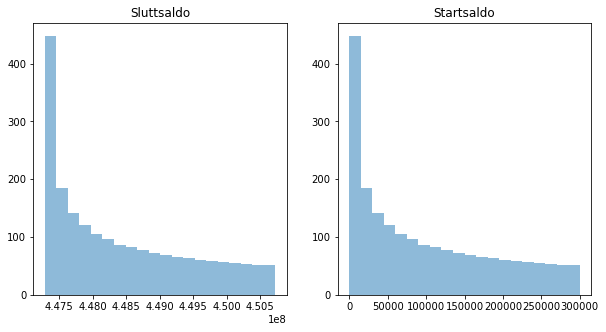

I snitt har kundene 100000 kr på konto ved start
    Kunden med lavest saldo har 0 på konto
    Kunden med høyest saldo har 300000 på konto

    I snitt har kundene 448431271 kr på konto ved slutt
    Kunden med lavest saldo har 447284531 på konto
    Kunden med høyest saldo har 450724750 på konto


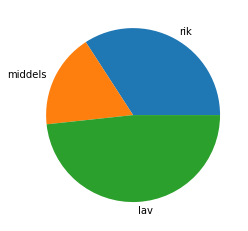

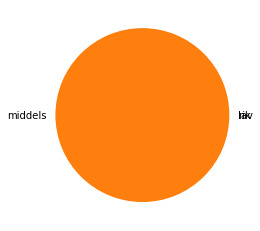

In [51]:

print(info)
t_slutt = 50
P_snitt = 1e3
P_std = 200.0

r_snitt = 0.05
r_std = 0.005

def lag_kundedata(P_snitt, P_std, r_snitt, r_std):
    P = np.random.normal(loc=P_snitt, scale=P_std)
    r = np.random.normal(loc=r_snitt, scale=r_std)
    return P,r

def oppdater_kundedata(kdata):
    for kunde in kdata:
        if kunde["segment"]["start"] == "rik":
            P, r = lag_kundedata(P_snitt*1.5, P_std, r_snitt*1.2, r_std)
        elif kunde["segment"]["start"] == "lav":
            P, r = lag_kundedata(P_snitt*0.8, P_std, r_snitt*0.9, r_std)
        else:
            P, r = lag_kundedata(P_snitt, P_std, r_snitt, r_std)
        kunde["terminbelop"] = P
        kunde["rente"] = r

def kalk_sluttsaldo2(kdata):
    for kunde in kdata:
        startsaldo = kunde["startsaldo"]
        kunde["sluttsaldo"] = sluttsaldo(kunde["terminbelop"], kunde["rente"], n, kunde["startsaldo"], t_slutt)

    # Iterer over listen og legg til en liste med årlig saldo fra start til sluttå for alle kunder

    for kunde in kdata:
        saldo = []
        for t in range(t_slutt+1):
            saldo_t = sluttsaldo(P,r,n,kunde["startsaldo"], t)
            saldo.append(saldo_t)
        kunde["saldo_liste"] = saldo    

kalk_sluttsaldo(kundedata)
startsaldo_liste, sluttsaldo_liste = plot_fordeling(kundedata)
data = oppdater_data(startsaldo_liste, sluttsaldo_liste)

kalk_segment(data)
kalk_segmentstorrelse("start", data)
kalk_segmentstorrelse("slutt", data)

segmentstorrelse = data["segment_storrelse"]["start"].values()
segmentstorrelse_labels = data["segment_storrelse"]["start"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()

segmentstorrelse = data["segment_storrelse"]["slutt"].values()
segmentstorrelse_labels = data["segment_storrelse"]["slutt"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()



    

# 4.3: Gini-indeks
* Vi bygger videre i på programmet i 4.2
* Les deg opp på Gini-indeks og Lorenzkurven
* Plott fordelingen av sparepenger etter lengre tid når ikke alle har samme sparebetingelser:
  - Vis dette med Lorenzkurven

  

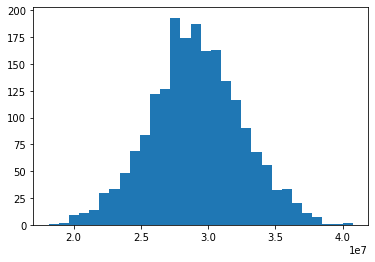

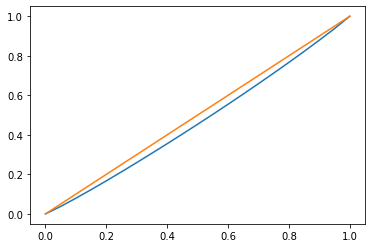

In [48]:
    
def plot_lorenz(saldo_liste):
    percentiler = np.linspace(0,1,21)
    kum_fordeling = []
    n = len(saldo_liste)
    total_spareformue = sum(saldo_liste)
    saldo_liste.sort()
    for p in percentiler:
        if p == 0.0:
            kum_fordeling.append(0.0)
            continue
        sluttindeks = int(round(p*n,0))
        andel_formue = sum(saldo_liste[:sluttindeks])/total_spareformue
        kum_fordeling.append(andel_formue)

    plt.hist(saldo_liste, 30)
    plt.show()
    plt.plot(percentiler, kum_fordeling)
    plt.plot([0,1],[0,1])
    plt.show()

plot_lorenz(sluttsaldo_liste)


# 4.4 Skjevfordelt startsaldo
* La oss anta at startsaldoen ikke er normalfordelt blant kundene
* Startfordelinger er heller gitt ved Lorenzkurven:  $L(x) = x^2$
* Gi kundene en startsaldo som tilsvarer denne Lorenzkurven og finn ut hva som skjer med fordelingen over tid
* Er det noe banken kan gjøre for å utligne forskjellene?

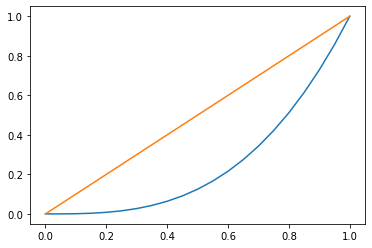

In [49]:
x = np.linspace(0,1,21)
y = x**3
plt.plot(x,y)
plt.plot([0,1],[0,1])
plt.show()

Listen inneholder data om 2000 kunder.
For hver kunde har vi data om ['fornavn', 'etternavn', 'startsaldo']


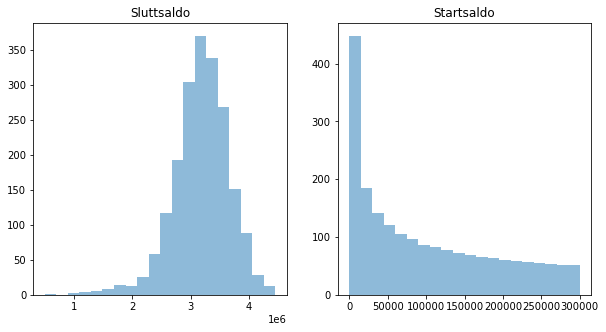

I snitt har kundene 100000 kr på konto ved start
    Kunden med lavest saldo har 0 på konto
    Kunden med høyest saldo har 300000 på konto

    I snitt har kundene 3183358 kr på konto ved slutt
    Kunden med lavest saldo har 491574 på konto
    Kunden med høyest saldo har 4461554 på konto


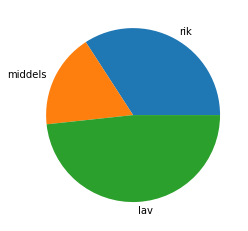

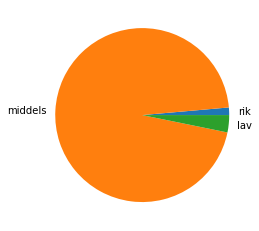

In [52]:
import json
with open("kundedata1.json", 'r') as file:
    kundedata = json.load(file)
info = f"""Listen inneholder data om {len(kundedata)} kunder.
For hver kunde har vi data om {list(kundedata[0].keys())}"""
print(info)

# Gå over kundelisten og legg inn sluttsaldo
# Vi sparer 1000kr/mnd, i 10 år, p.a. rente på 5%
P = 1000
r = 0.05
n=12
t_slutt = 1

def Lorenz(x):
    return x**3

def klassifiser_kunder_start(kdata):
    segmenter = {"rik": 0.9, "lav": 0.1}
    saldoliste = [kunde["startsaldo"] for kunde in kdata]
    n_over = 0
    n = len(saldoliste)
    for kunde in kdata:
        kunde["segment"] = dict()
        
        saldo = kunde["startsaldo"]
        for s in saldoliste:
            if s<saldo:
                n_over +=1
        if n_over/n >= segmenter["rik"]:
            kunde["segment"]["start"] = "rik"
        elif n_over/n <= segmenter["lav"]:
            kunde["segment"]["start"] = "lav"
        else:
            kunde["segment"]["start"] = "middels"

          
n = len(kundedata)
x = np.linspace(0.0,1.0,n)
gammel_total = 0.0
totSaldo = n*100e3
for xs, kunde in zip(x,kundedata):
    ny_total = Lorenz(xs)*totSaldo
    ny_saldo = ny_total-gammel_total
    gammel_total = ny_total
    kunde["startsaldo"] = ny_saldo


klassifiser_kunder_start(kundedata)
oppdater_kundedata(kundedata)
kalk_sluttsaldo2(kundedata)
startsaldo_liste, sluttsaldo_liste = plot_fordeling(kundedata)
data = oppdater_data(startsaldo_liste, sluttsaldo_liste)

kalk_segment(data)
kalk_segmentstorrelse("start", data)
kalk_segmentstorrelse("slutt", data)

segmentstorrelse = data["segment_storrelse"]["start"].values()
segmentstorrelse_labels = data["segment_storrelse"]["start"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()

segmentstorrelse = data["segment_storrelse"]["slutt"].values()
segmentstorrelse_labels = data["segment_storrelse"]["slutt"].keys()
plt.pie(segmentstorrelse, labels=segmentstorrelse_labels)
plt.show()